In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append('..')

from src.data.smd import SMDDataset, list_machines, _load_series, _load_labels

machines = list_machines()
print(f"Available: {len(machines)} machines")
print(machines[:5])

Available: 28 machines
['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5']


In [2]:
machine = "machine-1-1"
test_raw = _load_series(Path(f"../data/smd/test/{machine}.txt"))
labels = _load_labels(Path(f"../data/smd/test_label/{machine}.txt"))

print(f"Test shape: {test_raw.shape}")
print(f"Anomaly rate: {labels.mean():.3%}")

Test shape: (28479, 38)
Anomaly rate: 9.460%


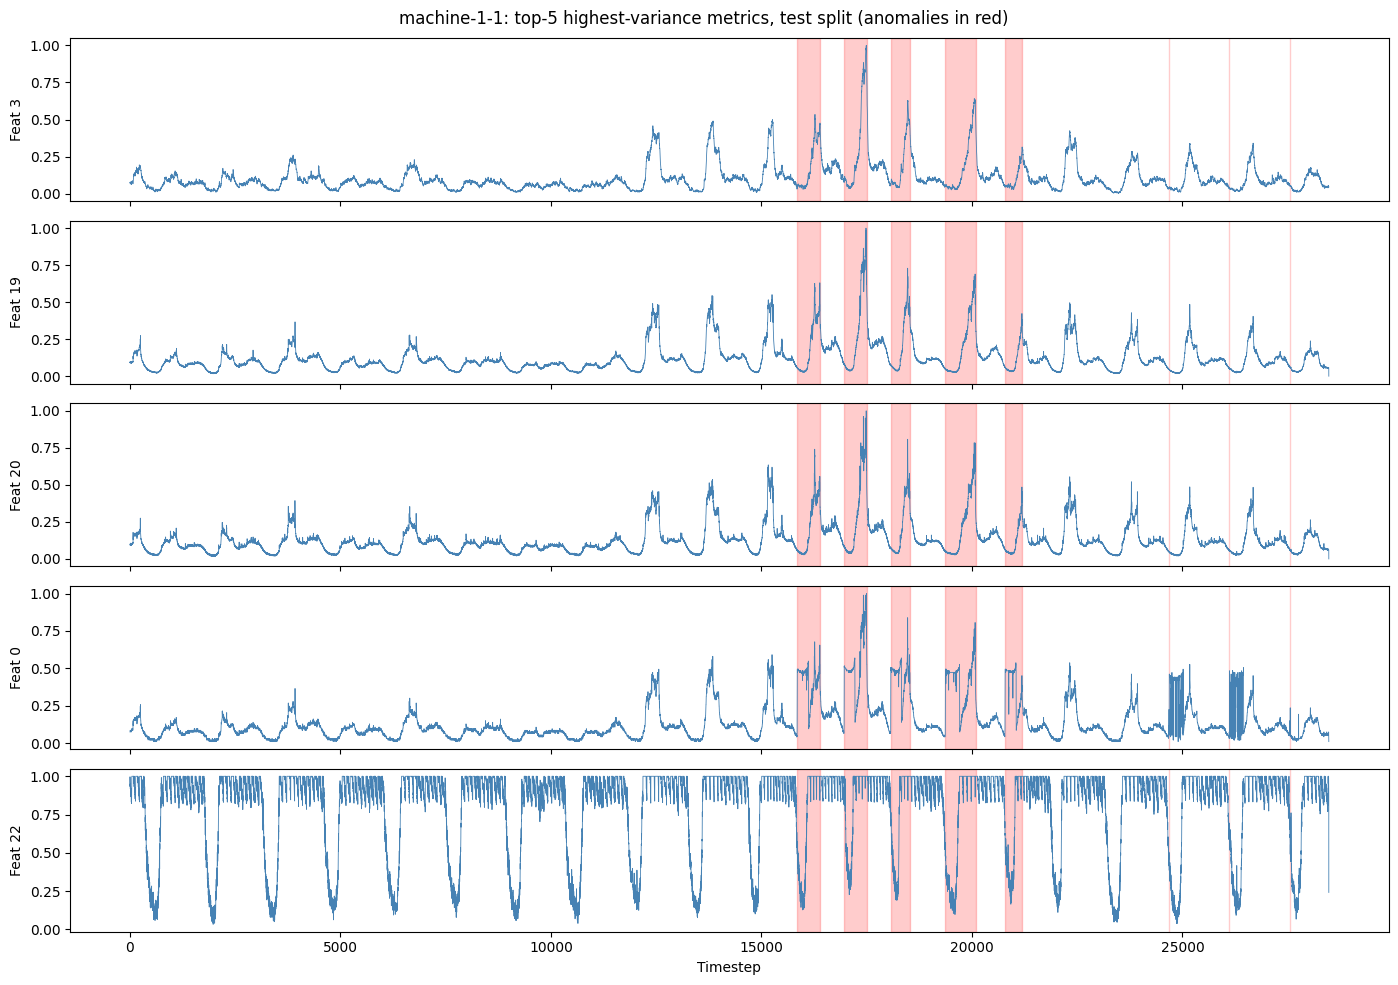

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

# Pick 5 metrics with the highest variance for visual interest
variances = test_raw.var(axis=0)
top5_idx = np.argsort(variances)[-5:]

for ax, feat_idx in zip(axes, top5_idx):
    ax.plot(test_raw[:, feat_idx], linewidth=0.6, color="steelblue")
    ax.set_ylabel(f"Feat {feat_idx}")
    
    # Shade anomaly regions
    in_anom = False
    start = 0
    for t, lab in enumerate(labels):
        if lab == 1 and not in_anom:
            start = t
            in_anom = True
        elif lab == 0 and in_anom:
            ax.axvspan(start, t, color="red", alpha=0.2)
            in_anom = False
    if in_anom:
        ax.axvspan(start, len(labels), color="red", alpha=0.2)

axes[-1].set_xlabel("Timestep")
fig.suptitle(f"{machine}: top-5 highest-variance metrics, test split (anomalies in red)")
plt.tight_layout()
plt.show()